In [84]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import math

In [94]:
np.random.seed(42)

days = 365
beds = 75
max_days_padded = days + 100


def generate_arrivals(t, ward):
    if ward == 'A':
        lambda_A = -(1/3650) * t**2 + (1/10) * t
        return np.random.poisson(max(0, lambda_A))
    if ward == 'B':
        lambda_A = -(1/3650) * t**2 + (1/10) * t
        lambda_B = (1/5) * lambda_A
        return np.random.poisson(max(0, lambda_B))
    if ward == 'C':
        return np.random.poisson(6)
        
def LOS(ward, arrivals):
    if arrivals == 0:
        return np.array([], dtype=int)
    
    sigma = np.sqrt(np.log(2))
    if ward == 'A':
        mu = np.log(4 * np.sqrt(2))
    elif ward == 'B':
        mu = np.log(6 * np.sqrt(2))
    elif ward == 'C':
        mu = np.log(5 * np.sqrt(2))
        
    los_days = np.ceil(np.random.lognormal(mean=mu, sigma=sigma, size=arrivals)).astype(int)
    return np.maximum(1, los_days)



def simulate_hospital(generate_arrivals, LOS, beds_A_alloc, beds_B_alloc, beds_C_alloc):
    blocking_fraction = []
    beds_A = np.full(max_days_padded, beds_A_alloc)
    beds_B = np.full(max_days_padded, beds_B_alloc)
    beds_C = np.full(max_days_padded, beds_C_alloc)

    total_arrivals = {'A': 0, 'B': 0, 'C': 0}
    blocked_counts = {'A': 0, 'B': 0, 'C': 0}
    
    utilization_A = []
    utilization_B = []
    utilization_C = []

    for t in range(0,days):
        blocked = 0
        arrivals_A = generate_arrivals(t,'A')
        arrivals_B = generate_arrivals(t,'B')
        arrivals_C = generate_arrivals(t,'C')

        total_arrivals['A'] += arrivals_A
        total_arrivals['B'] += arrivals_B
        total_arrivals['C'] += arrivals_C

        los_A = LOS('A', arrivals_A)
        los_B = LOS('B', arrivals_B)
        los_C = LOS('C', arrivals_C)

        for length in los_A:
            if np.all(beds_A[t:t+length] > 0):
                beds_A[t:t+length] -= 1
            else:
                blocked_counts['A'] += 1


        for length in los_B:
            if np.all(beds_B[t:t+length] > 0):
                beds_B[t:t+length] -= 1
            else:
                if np.all(beds_A[t:t+length] > 0):
                    beds_A[t:t+length] -= 1
                else:
                    blocked_counts['B'] += 1

        for length in los_C:
            if np.all(beds_C[t:t+length] > 0):
                beds_C[t:t+length] -= 1
            else:
                blocked_counts['C'] += 1
        
        utilization_A.append((beds_A_alloc - beds_A[t]) / beds_A_alloc)
        utilization_B.append((beds_B_alloc - beds_B[t]) / beds_B_alloc)
        utilization_C.append((beds_C_alloc - beds_C[t]) / beds_C_alloc)
                
    total_blocked = sum(blocked_counts.values())
    blocked_frac = total_blocked/sum(total_arrivals.values())
    blocked_ward_A = blocked_counts['A']/total_arrivals['A']
    blocked_ward_B = blocked_counts['B']/total_arrivals['B']
    blocked_ward_C = blocked_counts['C']/total_arrivals['C']
    mean_util_A = np.mean(utilization_A)
    mean_util_B = np.mean(utilization_B)
    mean_util_C = np.mean(utilization_C)

    return total_blocked, blocked_frac, blocked_ward_A, blocked_ward_B, blocked_ward_C, mean_util_A, mean_util_B, mean_util_C


In [102]:
import numpy as np

np.random.seed(42)

days = 365
beds = 75
max_days_padded = days + 100


def generate_arrivals(t, ward):
    if ward == 'A':
        lambda_A = -(1/3650) * t**2 + (1/10) * t
        return np.random.poisson(max(0, lambda_A))
    if ward == 'B':
        lambda_A = -(1/3650) * t**2 + (1/10) * t
        lambda_B = (1/5) * lambda_A
        return np.random.poisson(max(0, lambda_B))
    if ward == 'C':
        return np.random.poisson(6)
        
def LOS(ward, arrivals):
    if arrivals == 0:
        return np.array([], dtype=int)
    
    sigma = np.sqrt(np.log(2))
    if ward == 'A':
        mu = np.log(4 * np.sqrt(2))
    elif ward == 'B':
        mu = np.log(6 * np.sqrt(2))
    elif ward == 'C':
        mu = np.log(5 * np.sqrt(2))
        
    los_days = np.ceil(np.random.lognormal(mean=mu, sigma=sigma, size=arrivals)).astype(int)
    return np.maximum(1, los_days)



def simulate_hospital(generate_arrivals, LOS, beds_A_alloc, beds_B_alloc, beds_C_alloc):
    blocking_fraction = []
    beds_A = np.full(max_days_padded, beds_A_alloc)
    beds_B = np.full(max_days_padded, beds_B_alloc)
    beds_C = np.full(max_days_padded, beds_C_alloc)

    total_arrivals = {'A': 0, 'B': 0, 'C': 0}
    blocked_counts = {'A': 0, 'B': 0, 'C': 0}
    
    utilization_A = []
    utilization_B = []
    utilization_C = []

    for t in range(0,days):
        blocked = 0
        arrivals_A = generate_arrivals(t,'A')
        arrivals_B = generate_arrivals(t,'B')
        arrivals_C = generate_arrivals(t,'C')

        total_arrivals['A'] += arrivals_A
        total_arrivals['B'] += arrivals_B
        total_arrivals['C'] += arrivals_C

        los_A = LOS('A', arrivals_A)
        los_B = LOS('B', arrivals_B)
        los_C = LOS('C', arrivals_C)

        for length in los_A:
            # CHANGE: Check if bed is available ONLY at arrival time 't', not 'np.all' across the stay
            if beds_A[t] > 0:
                beds_A[t:t+length] -= 1
            else:
                blocked_counts['A'] += 1


        for length in los_B:
            # CHANGE: Check Ward B capacity ONLY at arrival time 't'
            if beds_B[t] > 0:
                beds_B[t:t+length] -= 1
            else:
                # CHANGE: Check Ward A overflow capacity ONLY at arrival time 't'
                if beds_A[t] > 0:
                    beds_A[t:t+length] -= 1
                else:
                    blocked_counts['B'] += 1

        for length in los_C:
            # CHANGE: Check Ward C capacity ONLY at arrival time 't'
            if beds_C[t] > 0:
                beds_C[t:t+length] -= 1
            else:
                blocked_counts['C'] += 1
        
        utilization_A.append((beds_A_alloc - beds_A[t]) / beds_A_alloc)
        utilization_B.append((beds_B_alloc - beds_B[t]) / beds_B_alloc)
        utilization_C.append((beds_C_alloc - beds_C[t]) / beds_C_alloc)
                
    total_blocked = sum(blocked_counts.values())
    
    # CHANGE: Added safety checks (if > 0) to prevent potential ZeroDivisionError 
    blocked_frac = total_blocked/sum(total_arrivals.values()) if sum(total_arrivals.values()) > 0 else 0
    blocked_ward_A = blocked_counts['A']/total_arrivals['A'] if total_arrivals['A'] > 0 else 0
    blocked_ward_B = blocked_counts['B']/total_arrivals['B'] if total_arrivals['B'] > 0 else 0
    blocked_ward_C = blocked_counts['C']/total_arrivals['C'] if total_arrivals['C'] > 0 else 0
    
    mean_util_A = np.mean(utilization_A)
    mean_util_B = np.mean(utilization_B)
    mean_util_C = np.mean(utilization_C)

    return total_blocked, blocked_frac, blocked_ward_A, blocked_ward_B, blocked_ward_C, mean_util_A, mean_util_B, mean_util_C

In [101]:
b_A = 35
b_B = 2
b_C = 38
simulate_hospital(generate_arrivals, LOS, b_A, b_B, b_C)

(2174,
 0.44704914661731443,
 0.43873873873873875,
 0.7203579418344519,
 0.3998178506375228,
 0.8706066536203523,
 0.9,
 0.9700793078586878)

In [103]:
best_config = None
min_relocated = float('inf')
results_log = []

step = 1
n_reps = 5  



for b_A in range(1, 75, step):
    for b_B in range(1, 75 - b_A, step):
        b_C = 75 - (b_A + b_B)
        
        if b_C < 5: 
            continue
            
        rep_blocked = []
        sim_frac = []
        ward_A = []
        ward_B = []
        ward_C = []
        util_A = []
        util_B = []
        util_C = []
        for rep in range(n_reps):
            sim_blocked, sim_blocked_frac, sim_ward_A, sim_ward_B, sim_ward_C, sim_util_A, sim_util_B, sim_util_C = simulate_hospital(generate_arrivals, LOS, b_A, b_B, b_C)
            rep_blocked.append(sim_blocked)
            sim_frac.append(sim_blocked_frac)
            ward_A.append(sim_ward_A)
            ward_B.append(sim_ward_B)
            ward_C.append(sim_ward_C)
            util_A.append(sim_util_A)
            util_B.append(sim_util_B)
            util_C.append(sim_util_C)
            
        avg_blocked = np.mean(rep_blocked)
        avg_frac = np.mean(sim_frac)
        avg_A = np.mean(ward_A)
        avg_B = np.mean(ward_B)
        avg_C = np.mean(ward_C)
        avg_util_A = np.mean(util_A)
        avg_util_B = np.mean(util_B)
        avg_util_C = np.mean(util_C)

        results_log.append(((b_A, b_B, b_C), avg_blocked, avg_frac, ward_A, ward_B, ward_C))
        
        if avg_blocked < min_relocated:
            min_relocated = avg_blocked
            best_config = (b_A, b_B, b_C)



In [104]:
print("\n--- Optimization Complete ---")
print(f"Optimal Bed Distribution (Ward A, Ward B, Ward C): {best_config}")
print(f"Minimum expected relocated patients: {min_relocated:.2f}")
print(f"Blocked fraction total: {avg_frac:.2f}")
print(f"Blocked frac from ward A: {avg_A:.2f}")
print(f"Blocked frac from ward B: {avg_B:.2f}")
print(f"Blocked frac from ward C: {avg_C:.2f}")
print(f"Utilization ward A: {avg_util_A:.2f}")
print(f"Utilization ward B: {avg_util_B:.2f}")
print(f"Utilization ward C: {avg_util_C:.2f}")



--- Optimization Complete ---
Optimal Bed Distribution (Ward A, Ward B, Ward C): (30, 2, 43)
Minimum expected relocated patients: 2111.00
Blocked fraction total: 0.50
Blocked frac from ward A: 0.12
Blocked frac from ward B: 0.42
Blocked frac from ward C: 0.91
Utilization ward A: 0.79
Utilization ward B: 0.93
Utilization ward C: 1.00


# Exponential

In [88]:
        
def LOS_exp(ward, arrivals):
    if arrivals == 0:
        return np.array([], dtype=int)
    
    sigma = np.sqrt(np.log(2))
    if ward == 'A':
        mu = 8
    elif ward == 'B':
        mu = 12
    elif ward == 'C':
        mu = 10
    
    los_days = np.ceil(np.random.exponential(scale=mu, size=arrivals)).astype(int)
    return np.maximum(1, los_days)




In [98]:
best_config = None
min_relocated = float('inf')
results_log = []

step = 1
n_reps = 5  



for b_A in range(1, 75, step):
    for b_B in range(1, 75 - b_A, step):
        b_C = 75 - (b_A + b_B)
        
        if b_C < 5: 
            continue
            
        rep_blocked = []
        sim_frac = []
        ward_A = []
        ward_B = []
        ward_C = []
        util_A = []
        util_B = []
        util_C = []
        for rep in range(n_reps):
            sim_blocked, sim_blocked_frac, sim_ward_A, sim_ward_B, sim_ward_C, sim_util_A, sim_util_B, sim_util_C = simulate_hospital(generate_arrivals, LOS_exp, b_A, b_B, b_C)
            rep_blocked.append(sim_blocked)
            sim_frac.append(sim_blocked_frac)
            ward_A.append(sim_ward_A)
            ward_B.append(sim_ward_B)
            ward_C.append(sim_ward_C)
            util_A.append(sim_util_A)
            util_B.append(sim_util_B)
            util_C.append(sim_util_C)
            
        avg_blocked = np.mean(rep_blocked)
        avg_frac = np.mean(sim_frac)
        avg_A = np.mean(ward_A)
        avg_B = np.mean(ward_B)
        avg_C = np.mean(ward_C)
        avg_util_A = np.mean(util_A)
        avg_util_B = np.mean(util_B)
        avg_util_C = np.mean(util_C)

        results_log.append(((b_A, b_B, b_C), avg_blocked, avg_frac, ward_A, ward_B, ward_C))
        
        if avg_blocked < min_relocated:
            min_relocated = avg_blocked
            best_config = (b_A, b_B, b_C)



print("\n--- Optimization Complete ---")
print(f"Optimal Bed Distribution (Ward A, Ward B, Ward C): {best_config}")
print(f"Minimum expected relocated patients: {min_relocated:.2f}")
print(f"Blocked fraction total: {avg_frac:.2f}")
print(f"Blocked frac from ward A: {avg_A:.2f}")
print(f"Blocked frac from ward B: {avg_B:.2f}")
print(f"Blocked frac from ward C: {avg_C:.2f}")
print(f"Utilization ward A: {avg_util_A:.2f}")
print(f"Utilization ward B: {avg_util_B:.2f}")
print(f"Utilization ward C: {avg_util_C:.2f}")



--- Optimization Complete ---
Optimal Bed Distribution (Ward A, Ward B, Ward C): (27, 4, 44)
Minimum expected relocated patients: 2129.80
Blocked fraction total: 0.52
Blocked frac from ward A: 0.13
Blocked frac from ward B: 0.40
Blocked frac from ward C: 0.92
Utilization ward A: 0.77
Utilization ward B: 0.94
Utilization ward C: 1.00


# More beds

In [ ]:
np.random.seed(42)

# Ændre her ift antal af senge
more_beds = 100

best_config = None
min_relocated = float('inf')
results_log = []

step = 1
n_reps = 5  



for b_A in range(1, more_beds, step):
    for b_B in range(1, more_beds - b_A, step):
        b_C = more_beds - (b_A + b_B)
        
        if b_C < 5: 
            continue
            
        rep_blocked = []
        sim_frac = []
        ward_A = []
        ward_B = []
        ward_C = []
        util_A = []
        util_B = []
        util_C = []
        for rep in range(n_reps):
            sim_blocked, sim_blocked_frac, sim_ward_A, sim_ward_B, sim_ward_C, sim_util_A, sim_util_B, sim_util_C = simulate_hospital(generate_arrivals, LOS, b_A, b_B, b_C)
            rep_blocked.append(sim_blocked)
            sim_frac.append(sim_blocked_frac)
            ward_A.append(sim_ward_A)
            ward_B.append(sim_ward_B)
            ward_C.append(sim_ward_C)
            util_A.append(sim_util_A)
            util_B.append(sim_util_B)
            util_C.append(sim_util_C)
            
        avg_blocked = np.mean(rep_blocked)
        avg_frac = np.mean(sim_frac)
        avg_A = np.mean(ward_A)
        avg_B = np.mean(ward_B)
        avg_C = np.mean(ward_C)
        avg_util_A = np.mean(util_A)
        avg_util_B = np.mean(util_B)
        avg_util_C = np.mean(util_C)

        results_log.append(((b_A, b_B, b_C), avg_blocked, avg_frac, ward_A, ward_B, ward_C))
        
        if avg_blocked < min_relocated:
            min_relocated = avg_blocked
            best_config = (b_A, b_B, b_C)



print("\n--- Optimization Complete ---")
print(f"Optimal Bed Distribution (Ward A, Ward B, Ward C): {best_config}")
print(f"Minimum expected relocated patients: {min_relocated:.2f}")
print(f"Blocked fraction total: {avg_frac:.2f}")
print(f"Blocked frac from ward A: {avg_A:.2f}")
print(f"Blocked frac from ward B: {avg_B:.2f}")
print(f"Blocked frac from ward C: {avg_C:.2f}")
print(f"Utilization ward A: {avg_util_A:.2f}")
print(f"Utilization ward B: {avg_util_B:.2f}")
print(f"Utilization ward C: {avg_util_C:.2f}")



--- Optimization Complete ---
Optimal Bed Distribution (Ward A, Ward B, Ward C): (30, 2, 43)
Minimum expected relocated patients: 2111.00
Blocked fraction total: 0.50
Blocked frac from ward A: 0.12
Blocked frac from ward B: 0.42
Blocked frac from ward C: 0.91
Utilization ward A: 0.79
Utilization ward B: 0.93
Utilization ward C: 1.00


# Markus

In [105]:
import matplotlib.pyplot as plt

## Pre generate arrivals and LOS

In [106]:
import numpy as np

def generate_arrivals(max_time=365, exponential=False):
    """
    Pre-generates all arrivals and lengths of stay (LOS) for a single year.
    Returns a list of sorted tuples: (arrival_time, patient_type, length_of_stay)
    """
    arrivals = []
    
    # Ward A (Regular): lambda_1(t) = -(1/3650)t^2 + (1/10)t
    t = 0
    max_lambda_A = 9.125 
    while True:
        t -= (1 / max_lambda_A) * np.log(np.random.rand())
        if t > max_time: break
        lambda_t = -(1/3650) * t**2 + 0.1 * t
        if np.random.rand() <= (lambda_t / max_lambda_A):
            sigma = np.sqrt(np.log(2))
            if exponential:
                los = np.random.exponential(scale=8)
            else:
                los = np.random.lognormal(mean=np.log(4*np.sqrt(2)), sigma=sigma)
            arrivals.append((t, 'A', los))

    # Ward B (Intensive): lambda_2(t) = 0.2 * lambda_1(t)
    t = 0
    max_lambda_B = 1.825 
    while True:
        t -= (1 / max_lambda_B) * np.log(np.random.rand())
        if t > max_time: break
        lambda_t = 0.2 * (-(1/3650) * t**2 + 0.1 * t)
        if np.random.rand() <= (lambda_t / max_lambda_B):
            sigma = np.sqrt(np.log(2))
            if exponential:
                los = np.random.exponential(scale=12)
            else:
                los = np.random.lognormal(mean=np.log(6*np.sqrt(2)), sigma=sigma)
            arrivals.append((t, 'B', los))

    # Ward C (Other): Homogeneous Poisson Process, lambda_3 = 6
    t = 0
    lambda_C = 6
    while True:
        t -= (1 / lambda_C) * np.log(np.random.rand())
        if t > max_time: break
        sigma = np.sqrt(np.log(2))
        if exponential:
            los = np.random.exponential(scale=10)
        else:
            los = np.random.lognormal(mean=np.log(5*np.sqrt(2)), sigma=sigma)
        arrivals.append((t, 'C', los))

    # Sort all arrivals chronologically
    arrivals.sort(key=lambda x: x[0])
    return arrivals

n_replications = 5
replications_data_cont_lognormal = []
replications_data_cont_exponential = []

for i in range(n_replications):
    # Set a unique seed per replication to make them reproducible
    np.random.seed(42 + i)
    replications_data_cont_lognormal.append(generate_arrivals(max_time=365))
    replications_data_cont_exponential.append(generate_arrivals(max_time=365, exponential=True))

print(f"Pre-generated arrivals and stays for {n_replications} replications.")

Pre-generated arrivals and stays for 5 replications.


In [107]:
import numpy as np

def generate_arrivals_discrete(max_time=365, exponential=False):
    """
    Generates arrivals day-by-day using Poisson distributions.
    Returns a list of sorted tuples: (arrival_time, patient_type, length_of_stay)
    """
    arrivals = []
    sigma = np.sqrt(np.log(2))
    
    for d in range(max_time+1):
        # We evaluate the rate at the midpoint of the day (d + 0.5)
        t_mid = d + 0.5
        
        # --- 1. Ward A (Regular) ---
        lambda_A = max(0, -(1/3650) * (t_mid**2) + 0.1 * t_mid)
        # Sample the number of arrivals for this day
        n_A = np.random.poisson(lambda_A)
        
        for _ in range(n_A):
            arrival_time = d + np.random.rand()
            if exponential:
                los = np.random.exponential(scale=8)
            else:
                los = np.random.lognormal(mean=np.log(4*np.sqrt(2)), sigma=sigma)
            arrivals.append((arrival_time, 'A', los))
            
        # --- 2. Ward B (Intensive) ---
        lambda_B = 0.2 * lambda_A
        n_B = np.random.poisson(lambda_B)
        for _ in range(n_B):
            arrival_time = d + np.random.rand()
            if exponential:
                los = np.random.exponential(scale=12)
            else:
                los = np.random.lognormal(mean=np.log(6*np.sqrt(2)), sigma=sigma)
            arrivals.append((arrival_time, 'B', los))
            
        # --- 3. Ward C (Other) ---
        lambda_C = 6.0
        n_C = np.random.poisson(lambda_C)
        for _ in range(n_C):
            arrival_time = d + np.random.rand()
            if exponential:
                los = np.random.exponential(scale=10)
            else:
                los = np.random.lognormal(mean=np.log(5*np.sqrt(2)), sigma=sigma)
            arrivals.append((arrival_time, 'C', los))
            
    arrivals.sort(key=lambda x: x[0])
    return arrivals



n_replications = 5
replications_data_disc_lognormal = []
replications_data_disc_exponential = []

for i in range(n_replications):
    # Set a unique seed per replication to make them reproducible
    np.random.seed(42 + i)
    replications_data_disc_lognormal.append(generate_arrivals_discrete(max_time=365))
    replications_data_disc_exponential.append(generate_arrivals_discrete(max_time=365, exponential=True))

print(f"Pre-generated arrivals and stays for {n_replications} replications.")

Pre-generated arrivals and stays for 5 replications.


## Plot arrivals and LOS

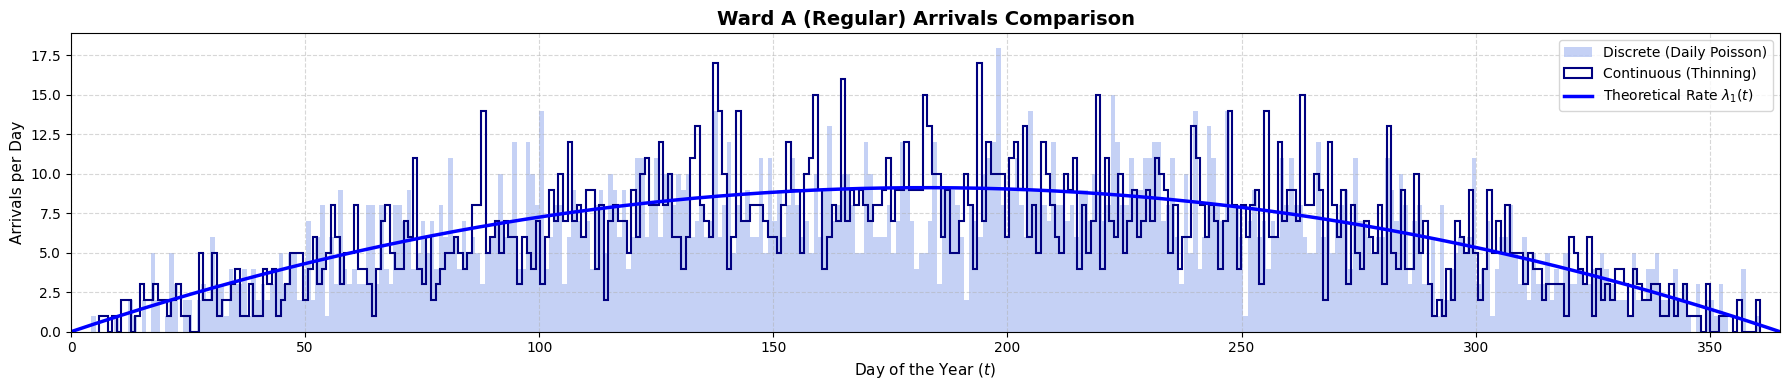

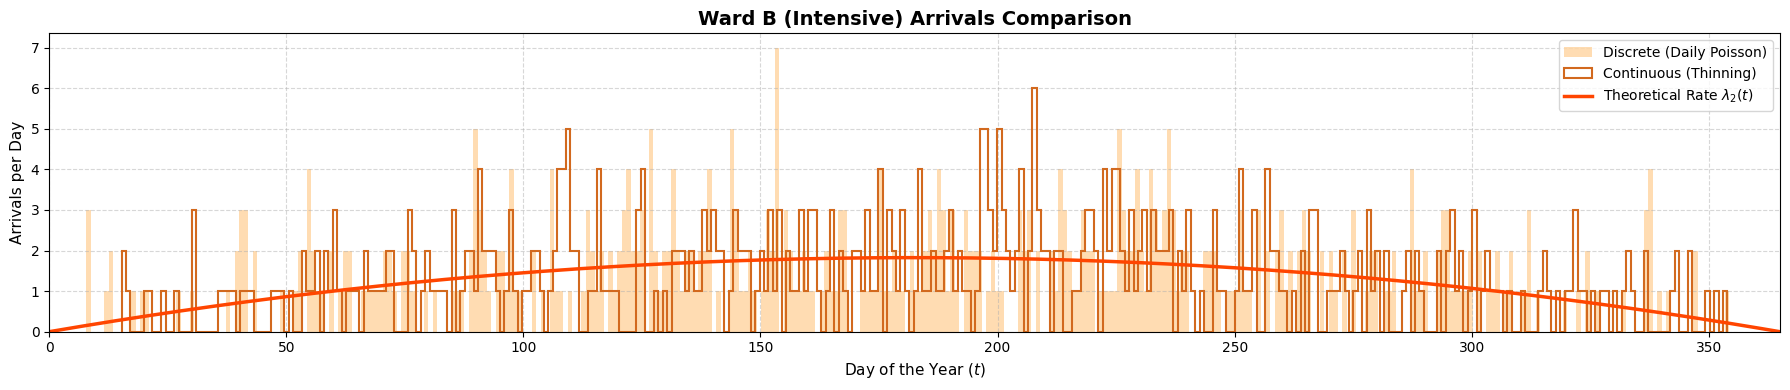

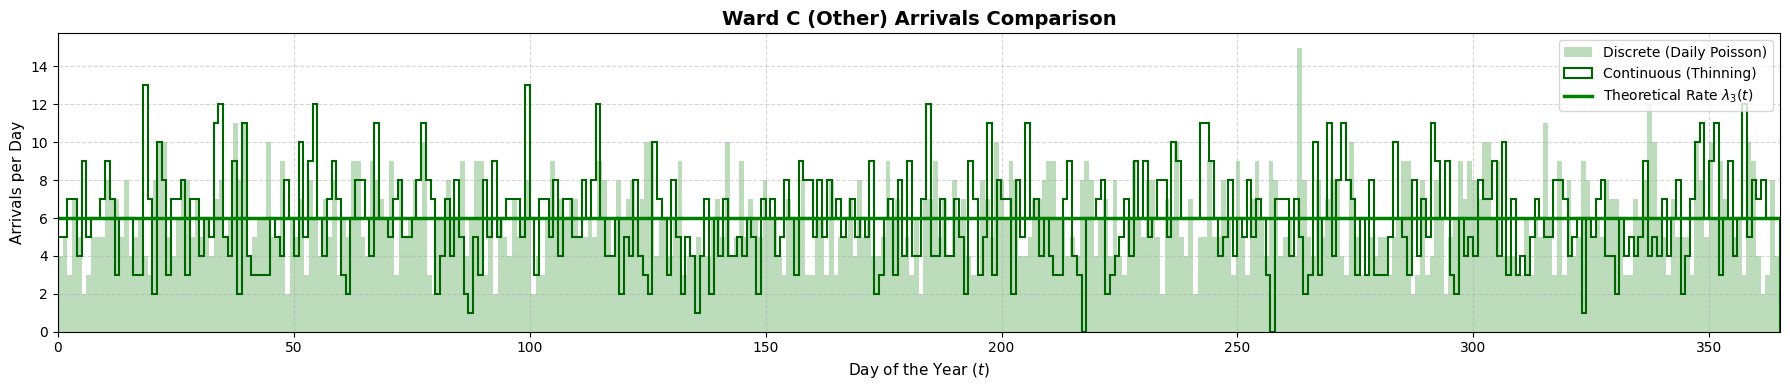

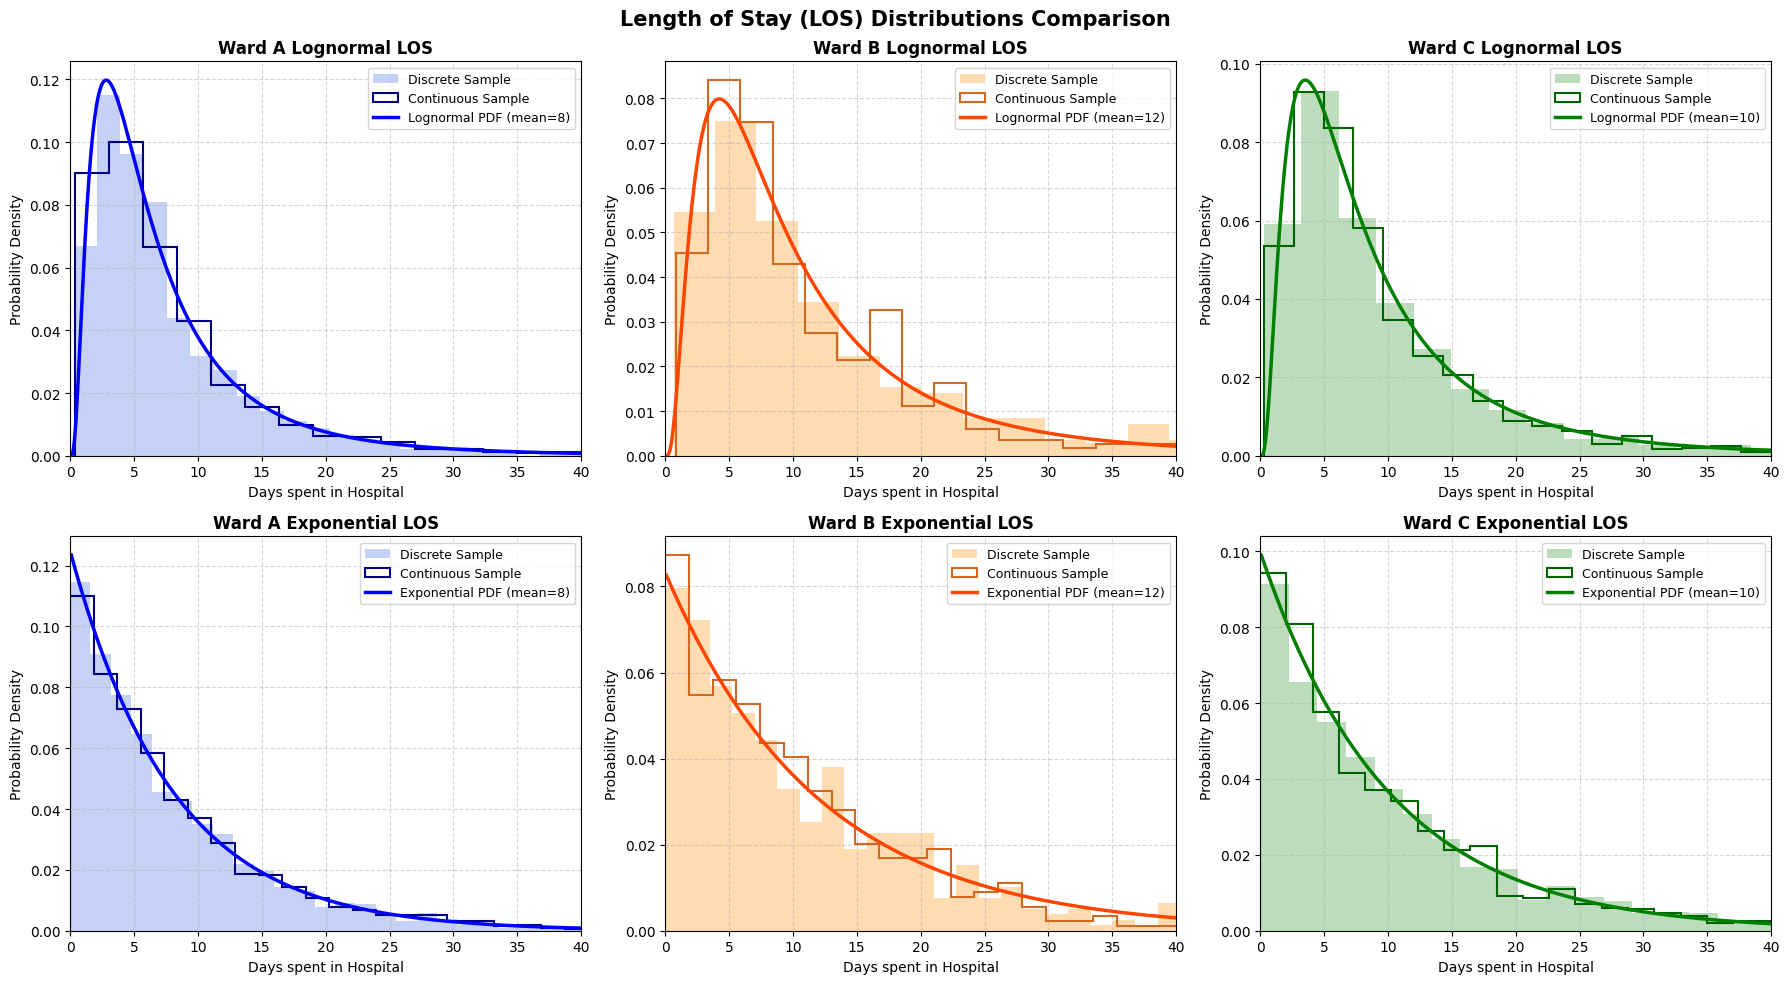

--- TOTAL ARRIVALS FOR THE YEAR (Replication 0) ---
Continuous Lognormal: Ward A = 2171 | Ward B = 461 | Ward C = 2159 | Total = 4791
Discrete Lognormal:   Ward A = 2201 | Ward B = 442 | Ward C = 2194 | Total = 4837


In [108]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. Extract the first replication of all pre-generated datasets
arrivals_cont_log = replications_data_cont_lognormal[0]
arrivals_cont_exp = replications_data_cont_exponential[0]
arrivals_disc_log = replications_data_disc_lognormal[0]
arrivals_disc_exp = replications_data_disc_exponential[0]

# --- Extract Continuous Lognormal Data (for Arrival times) ---
times_cont_A = [t for t, p_type, los in arrivals_cont_log if p_type == 'A']
times_cont_B = [t for t, p_type, los in arrivals_cont_log if p_type == 'B']
times_cont_C = [t for t, p_type, los in arrivals_cont_log if p_type == 'C']

# --- Extract Discrete Lognormal Data (for Arrival times) ---
times_disc_A = [t for t, p_type, los in arrivals_disc_log if p_type == 'A']
times_disc_B = [t for t, p_type, los in arrivals_disc_log if p_type == 'B']
times_disc_C = [t for t, p_type, los in arrivals_disc_log if p_type == 'C']

# --- Extract Lognormal Length of Stay ---
los_cont_log_A = [los for t, p_type, los in arrivals_cont_log if p_type == 'A']
los_cont_log_B = [los for t, p_type, los in arrivals_cont_log if p_type == 'B']
los_cont_log_C = [los for t, p_type, los in arrivals_cont_log if p_type == 'C']

los_disc_log_A = [los for t, p_type, los in arrivals_disc_log if p_type == 'A']
los_disc_log_B = [los for t, p_type, los in arrivals_disc_log if p_type == 'B']
los_disc_log_C = [los for t, p_type, los in arrivals_disc_log if p_type == 'C']

# --- Extract Exponential Length of Stay ---
los_cont_exp_A = [los for t, p_type, los in arrivals_cont_exp if p_type == 'A']
los_cont_exp_B = [los for t, p_type, los in arrivals_cont_exp if p_type == 'B']
los_cont_exp_C = [los for t, p_type, los in arrivals_cont_exp if p_type == 'C']

los_disc_exp_A = [los for t, p_type, los in arrivals_disc_exp if p_type == 'A']
los_disc_exp_B = [los for t, p_type, los in arrivals_disc_exp if p_type == 'B']
los_disc_exp_C = [los for t, p_type, los in arrivals_disc_exp if p_type == 'C']


# 2. Define Theoretical Grids
t_grid = np.linspace(0, 365, 1000)
rate_A_theoretical = -(1/3650) * (t_grid**2) + 0.1 * t_grid
rate_B_theoretical = 0.2 * rate_A_theoretical
rate_C_theoretical = np.ones_like(t_grid) * 6.0

sigma = np.sqrt(np.log(2))
los_grid = np.linspace(0.1, 40, 500)


# =====================================================================
# STANDALONE ARRIVAL PLOTS (Full-Width, 3x wider)
# =====================================================================

# --- Plot 1: Ward A Arrivals ---
plt.figure(figsize=(18, 4.0))
plt.hist(times_disc_A, bins=365, color='royalblue', alpha=0.3, label='Discrete (Daily Poisson)')
plt.hist(times_cont_A, bins=365, histtype='step', color='navy', linewidth=1.5, label='Continuous (Thinning)')
plt.plot(t_grid, rate_A_theoretical, color='blue', linewidth=2.5, label='Theoretical Rate $\lambda_1(t)$')
plt.title('Ward A (Regular) Arrivals Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Day of the Year ($t$)', fontsize=11)
plt.ylabel('Arrivals per Day', fontsize=11)
plt.xlim(0, 365)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10, loc='upper right')
plt.tight_layout()
plt.show()

# --- Plot 2: Ward B Arrivals ---
plt.figure(figsize=(18, 4.0))
plt.hist(times_disc_B, bins=365, color='darkorange', alpha=0.3, label='Discrete (Daily Poisson)')
plt.hist(times_cont_B, bins=365, histtype='step', color='chocolate', linewidth=1.5, label='Continuous (Thinning)')
plt.plot(t_grid, rate_B_theoretical, color='orangered', linewidth=2.5, label='Theoretical Rate $\lambda_2(t)$')
plt.title('Ward B (Intensive) Arrivals Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Day of the Year ($t$)', fontsize=11)
plt.ylabel('Arrivals per Day', fontsize=11)
plt.xlim(0, 365)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10, loc='upper right')
plt.tight_layout()
plt.show()

# --- Plot 3: Ward C Arrivals ---
plt.figure(figsize=(18, 4.0))
plt.hist(times_disc_C, bins=365, color='forestgreen', alpha=0.3, label='Discrete (Daily Poisson)')
plt.hist(times_cont_C, bins=365, histtype='step', color='darkgreen', linewidth=1.5, label='Continuous (Thinning)')
plt.plot(t_grid, rate_C_theoretical, color='green', linewidth=2.5, label='Theoretical Rate $\lambda_3(t)$')
plt.title('Ward C (Other) Arrivals Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Day of the Year ($t$)', fontsize=11)
plt.ylabel('Arrivals per Day', fontsize=11)
plt.xlim(0, 365)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10, loc='upper right')
plt.tight_layout()
plt.show()


# =====================================================================
# SUBPLOTS: LENGTH OF STAY (LOS) COMPARISON (2 Rows x 3 Columns)
# =====================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plt.subplots_adjust(hspace=0.35, wspace=0.25)

# ----------------------------------------------
# ROW 1: LOGNORMAL LENGTH OF STAY (From pre-generated lognormal dataset)
# ----------------------------------------------
# --- Subplot 1: Ward A Lognormal ---
pdf_log_A = stats.lognorm.pdf(los_grid, s=sigma, scale=4*np.sqrt(2))
axes[0, 0].hist(los_disc_log_A, bins=40, density=True, color='royalblue', alpha=0.3, label='Discrete Sample')
axes[0, 0].hist(los_cont_log_A, bins=40, density=True, histtype='step', color='navy', linewidth=1.5, label='Continuous Sample')
axes[0, 0].plot(los_grid, pdf_log_A, color='blue', linewidth=2.5, label='Lognormal PDF (mean=8)')
axes[0, 0].set_title('Ward A Lognormal LOS', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Days spent in Hospital', fontsize=10)
axes[0, 0].set_ylabel('Probability Density', fontsize=10)
axes[0, 0].set_xlim(0, 40)
axes[0, 0].grid(True, linestyle='--', alpha=0.5)
axes[0, 0].legend(fontsize=9)

# --- Subplot 2: Ward B Lognormal ---
pdf_log_B = stats.lognorm.pdf(los_grid, s=sigma, scale=6*np.sqrt(2))
axes[0, 1].hist(los_disc_log_B, bins=40, density=True, color='darkorange', alpha=0.3, label='Discrete Sample')
axes[0, 1].hist(los_cont_log_B, bins=40, density=True, histtype='step', color='chocolate', linewidth=1.5, label='Continuous Sample')
axes[0, 1].plot(los_grid, pdf_log_B, color='orangered', linewidth=2.5, label='Lognormal PDF (mean=12)')
axes[0, 1].set_title('Ward B Lognormal LOS', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Days spent in Hospital', fontsize=10)
axes[0, 1].set_ylabel('Probability Density', fontsize=10)
axes[0, 1].set_xlim(0, 40)
axes[0, 1].grid(True, linestyle='--', alpha=0.5)
axes[0, 1].legend(fontsize=9)

# --- Subplot 3: Ward C Lognormal ---
pdf_log_C = stats.lognorm.pdf(los_grid, s=sigma, scale=5*np.sqrt(2))
axes[0, 2].hist(los_disc_log_C, bins=40, density=True, color='forestgreen', alpha=0.3, label='Discrete Sample')
axes[0, 2].hist(los_cont_log_C, bins=40, density=True, histtype='step', color='darkgreen', linewidth=1.5, label='Continuous Sample')
axes[0, 2].plot(los_grid, pdf_log_C, color='green', linewidth=2.5, label='Lognormal PDF (mean=10)')
axes[0, 2].set_title('Ward C Lognormal LOS', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Days spent in Hospital', fontsize=10)
axes[0, 2].set_ylabel('Probability Density', fontsize=10)
axes[0, 2].set_xlim(0, 40)
axes[0, 2].grid(True, linestyle='--', alpha=0.5)
axes[0, 2].legend(fontsize=9)


# ----------------------------------------------
# ROW 2: EXPONENTIAL LENGTH OF STAY (From pre-generated exponential dataset)
# ----------------------------------------------
# --- Subplot 4: Ward A Exponential ---
pdf_exp_A = stats.expon.pdf(los_grid, scale=8.0)
axes[1, 0].hist(los_disc_exp_A, bins=40, density=True, color='royalblue', alpha=0.3, label='Discrete Sample')
axes[1, 0].hist(los_cont_exp_A, bins=40, density=True, histtype='step', color='navy', linewidth=1.5, label='Continuous Sample')
axes[1, 0].plot(los_grid, pdf_exp_A, color='blue', linewidth=2.5, label='Exponential PDF (mean=8)')
axes[1, 0].set_title('Ward A Exponential LOS', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Days spent in Hospital', fontsize=10)
axes[1, 0].set_ylabel('Probability Density', fontsize=10)
axes[1, 0].set_xlim(0, 40)
axes[1, 0].grid(True, linestyle='--', alpha=0.5)
axes[1, 0].legend(fontsize=9)

# --- Subplot 5: Ward B Exponential ---
pdf_exp_B = stats.expon.pdf(los_grid, scale=12.0)
axes[1, 1].hist(los_disc_exp_B, bins=40, density=True, color='darkorange', alpha=0.3, label='Discrete Sample')
axes[1, 1].hist(los_cont_exp_B, bins=40, density=True, histtype='step', color='chocolate', linewidth=1.5, label='Continuous Sample')
axes[1, 1].plot(los_grid, pdf_exp_B, color='orangered', linewidth=2.5, label='Exponential PDF (mean=12)')
axes[1, 1].set_title('Ward B Exponential LOS', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Days spent in Hospital', fontsize=10)
axes[1, 1].set_ylabel('Probability Density', fontsize=10)
axes[1, 1].set_xlim(0, 40)
axes[1, 1].grid(True, linestyle='--', alpha=0.5)
axes[1, 1].legend(fontsize=9)

# --- Subplot 6: Ward C Exponential ---
pdf_exp_C = stats.expon.pdf(los_grid, scale=10.0)
axes[1, 2].hist(los_disc_exp_C, bins=40, density=True, color='forestgreen', alpha=0.3, label='Discrete Sample')
axes[1, 2].hist(los_cont_exp_C, bins=40, density=True, histtype='step', color='darkgreen', linewidth=1.5, label='Continuous Sample')
axes[1, 2].plot(los_grid, pdf_exp_C, color='green', linewidth=2.5, label='Exponential PDF (mean=10)')
axes[1, 2].set_title('Ward C Exponential LOS', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Days spent in Hospital', fontsize=10)
axes[1, 2].set_ylabel('Probability Density', fontsize=10)
axes[1, 2].set_xlim(0, 40)
axes[1, 2].grid(True, linestyle='--', alpha=0.5)
axes[1, 2].legend(fontsize=9)

plt.suptitle('Length of Stay (LOS) Distributions Comparison', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# 4. Print printouts comparing totals
print(f"--- TOTAL ARRIVALS FOR THE YEAR (Replication 0) ---")
print(f"Continuous Lognormal: Ward A = {len(times_cont_A):4d} | Ward B = {len(times_cont_B):3d} | Ward C = {len(times_cont_C):4d} | Total = {len(arrivals_cont_log):4d}")
print(f"Discrete Lognormal:   Ward A = {len(times_disc_A):4d} | Ward B = {len(times_disc_B):3d} | Ward C = {len(times_disc_C):4d} | Total = {len(arrivals_disc_log):4d}")

## Main hospital simulation

In [109]:
def simulate_hospital(cap_A, cap_B, cap_C, arrivals, max_time=365):
    # Lists to store the departure times of patients currently in beds
    beds_A = []
    beds_B = []
    beds_C = []
    
    arrivals_count = {'A': 0, 'B': 0, 'C': 0}
    relocated = {'A': 0, 'B': 0, 'C': 0}
    util_integral = {'A': 0.0, 'B': 0.0, 'C': 0.0}
    
    for t, p_type, los in arrivals:
        # 1. Update occupancy: remove patients who have already departed before time t
        beds_A = [dep for dep in beds_A if dep > t]
        beds_B = [dep for dep in beds_B if dep > t]
        beds_C = [dep for dep in beds_C if dep > t]
        
        # 2. Process the arrival
        arrivals_count[p_type] += 1
        departure_time = t + los
        
        if p_type == 'C':
            if len(beds_C) < cap_C:
                beds_C.append(departure_time)
                util_integral['C'] += los
            else:
                relocated['C'] += 1
                
        elif p_type == 'B':
            if len(beds_B) < cap_B:
                beds_B.append(departure_time)
                util_integral['B'] += los
            elif len(beds_A) < cap_A: # Overflow to Ward A
                beds_A.append(departure_time)
                util_integral['A'] += los
            else:
                relocated['B'] += 1
                
        elif p_type == 'A':
            if len(beds_A) < cap_A:
                beds_A.append(departure_time)
                util_integral['A'] += los
            else:
                relocated['A'] += 1
                
    # Calculate final results
    blocking_prob = {
        k: (relocated[k] / arrivals_count[k] if arrivals_count[k] > 0 else 0) 
        for k in ['A', 'B', 'C']
    }
    
    avg_utilization = {
        'A': util_integral['A'] / (cap_A * max_time) if cap_A > 0 else 0,
        'B': util_integral['B'] / (cap_B * max_time) if cap_B > 0 else 0,
        'C': util_integral['C'] / (cap_C * max_time) if cap_C > 0 else 0
    }
    
    total_relocated = sum(relocated.values())
    total_arrivals = sum(arrivals_count.values())
    total_blocking_prob = total_relocated / total_arrivals if total_arrivals > 0 else 0

    return {
        "arrivals": arrivals_count,
        "relocated": relocated,
        "blocking_probabilities": blocking_prob,
        "total_blocking_probability": total_blocking_prob,
        "total_relocated": total_relocated,
        "avg_utilization": avg_utilization
    }

## Optimal bed distributions for various number of beds

In [114]:
# 75 lognormal

from tqdm.notebook import tqdm

CONTINUOUS = False
EXPONENTIAL = False
INTENSIVE_WEIGHT = 1

total_beds = 75
min_beds = 0

best_allocation = None
min_avg_weighted_relocated = float('inf')
normal_relocated_for_best = float('inf')

if CONTINUOUS:
    if EXPONENTIAL:
        replications_data = replications_data_cont_exponential
    else:
        replications_data = replications_data_cont_lognormal
else:
    if EXPONENTIAL:
        replications_data = replications_data_disc_exponential
    else:
        replications_data = replications_data_disc_lognormal

print(f"Starting grid search. Evaluating combinations for {total_beds} beds...")
print(f"Running {n_replications} replications per combination.\n")

for cap_A in tqdm(range(min_beds, total_beds - 2*min_beds + 1), desc="Grid Search Progress"):
    for cap_B in range(min_beds, total_beds - cap_A - min_beds + 1):
        cap_C = total_beds - cap_A - cap_B
        
        relocated_counts = [] 
        B_relocations = []
        results = []
        for rep_arrivals in replications_data:
            res = simulate_hospital(cap_A, cap_B, cap_C, rep_arrivals, max_time=365)
            results.append(res)
            B_relocations.append(res['relocated']['B'])
            relocated_counts.append(res['total_relocated'])
            
        avg_relocated = np.mean(relocated_counts)
        avg_B_relocations = np.mean(B_relocations)
        
        average_results = {"Beds": (cap_A, cap_B, cap_C)}
        for key in results[0].keys():
   
            if isinstance(results[0][key], dict):
                average_results[key] = {
                    sub_key: np.mean([res[key][sub_key] for res in results])
                    for sub_key in results[0][key].keys()
                }
            else:
                average_results[key] = np.mean([res[key] for res in results])
        
        weighted_avg_relocated = avg_relocated + (INTENSIVE_WEIGHT-1) * avg_B_relocations
        
        if weighted_avg_relocated < min_avg_weighted_relocated:
            min_avg_weighted_relocated = weighted_avg_relocated
            best_allocation = (cap_A, cap_B, cap_C)
            best_results = average_results
            
            normal_relocated_for_best = min_avg_weighted_relocated - (INTENSIVE_WEIGHT-1) * avg_B_relocations
            
            print(f"New Best Found -> Ward A: {cap_A:2d} | Ward B: {cap_B:2d} | Ward C: {cap_C:2d} " 
                  f"| Expected Relocations: {normal_relocated_for_best:.2f}", end='\r')

best_results

Starting grid search. Evaluating combinations for 75 beds...
Running 5 replications per combination.



Grid Search Progress:   0%|          | 0/76 [00:00<?, ?it/s]

{'Beds': (35, 0, 40),
 'arrivals': {'A': 2197.4, 'B': 437.8, 'C': 2186.0},
 'relocated': {'A': 1113.0, 'B': 218.2, 'C': 754.0},
 'blocking_probabilities': {'A': 0.50652225265527,
  'B': 0.49800594526724956,
  'C': 0.3448807009345657},
 'total_blocking_probability': 0.4325084165278502,
 'total_relocated': 2085.2,
 'avg_utilization': {'A': 0.8691218734438679,
  'B': 0.0,
  'C': 0.9730292949537155}}

In [111]:
# 75 lognormal

from tqdm.notebook import tqdm

CONTINUOUS = False
EXPONENTIAL = False
INTENSIVE_WEIGHT = 3

total_beds = 75
min_beds = 1

best_allocation = None
min_avg_weighted_relocated = float('inf')
normal_relocated_for_best = float('inf')

if CONTINUOUS:
    if EXPONENTIAL:
        replications_data = replications_data_cont_exponential
    else:
        replications_data = replications_data_cont_lognormal
else:
    if EXPONENTIAL:
        replications_data = replications_data_disc_exponential
    else:
        replications_data = replications_data_disc_lognormal

print(f"Starting grid search. Evaluating combinations for {total_beds} beds...")
print(f"Running {n_replications} replications per combination.\n")

for cap_A in tqdm(range(min_beds, total_beds - 2*min_beds + 1), desc="Grid Search Progress"):
    for cap_B in range(min_beds, total_beds - cap_A - min_beds + 1):
        cap_C = total_beds - cap_A - cap_B
        
        relocated_counts = [] 
        B_relocations = []
        results = []
        for rep_arrivals in replications_data:
            res = simulate_hospital(cap_A, cap_B, cap_C, rep_arrivals, max_time=365)
            results.append(res)
            B_relocations.append(res['relocated']['B'])
            relocated_counts.append(res['total_relocated'])
            
        avg_relocated = np.mean(relocated_counts)
        avg_B_relocations = np.mean(B_relocations)
        
        average_results = {"Beds": (cap_A, cap_B, cap_C)}
        for key in results[0].keys():
   
            if isinstance(results[0][key], dict):
                average_results[key] = {
                    sub_key: np.mean([res[key][sub_key] for res in results])
                    for sub_key in results[0][key].keys()
                }
            else:
                average_results[key] = np.mean([res[key] for res in results])
        
        weighted_avg_relocated = avg_relocated + (INTENSIVE_WEIGHT-1) * avg_B_relocations
        
        if weighted_avg_relocated < min_avg_weighted_relocated:
            min_avg_weighted_relocated = weighted_avg_relocated
            best_allocation = (cap_A, cap_B, cap_C)
            best_results = average_results
            
            normal_relocated_for_best = min_avg_weighted_relocated - (INTENSIVE_WEIGHT-1) * avg_B_relocations
            
            print(f"New Best Found -> Ward A: {cap_A:2d} | Ward B: {cap_B:2d} | Ward C: {cap_C:2d} " 
                  f"| Expected Relocations: {normal_relocated_for_best:.2f}", end='\r')

best_results

Starting grid search. Evaluating combinations for 75 beds...
Running 5 replications per combination.



Grid Search Progress:   0%|          | 0/73 [00:00<?, ?it/s]

{'Beds': (34, 15, 26),
 'arrivals': {'A': 2197.4, 'B': 437.8, 'C': 2186.0},
 'relocated': {'A': 954.6, 'B': 62.6, 'C': 1230.2},
 'blocking_probabilities': {'A': 0.4344654211841557,
  'B': 0.14265132617299642,
  'C': 0.56274411373521},
 'total_blocking_probability': 0.46615497786172444,
 'total_relocated': 2247.4,
 'avg_utilization': {'A': 0.8355719025966069,
  'B': 0.7160704501826632,
  'C': 0.9926361396745437}}

In [113]:
# 75 lognormal

from tqdm.notebook import tqdm

CONTINUOUS = False
EXPONENTIAL = False
INTENSIVE_WEIGHT = 2

total_beds = 75
min_beds = 1

best_allocation = None
min_avg_weighted_relocated = float('inf')
normal_relocated_for_best = float('inf')

if CONTINUOUS:
    if EXPONENTIAL:
        replications_data = replications_data_cont_exponential
    else:
        replications_data = replications_data_cont_lognormal
else:
    if EXPONENTIAL:
        replications_data = replications_data_disc_exponential
    else:
        replications_data = replications_data_disc_lognormal

print(f"Starting grid search. Evaluating combinations for {total_beds} beds...")
print(f"Running {n_replications} replications per combination.\n")

for cap_A in tqdm(range(min_beds, total_beds - 2*min_beds + 1), desc="Grid Search Progress"):
    for cap_B in range(min_beds, total_beds - cap_A - min_beds + 1):
        cap_C = total_beds - cap_A - cap_B
        
        relocated_counts = [] 
        B_relocations = []
        results = []
        for rep_arrivals in replications_data:
            res = simulate_hospital(cap_A, cap_B, cap_C, rep_arrivals, max_time=365)
            results.append(res)
            B_relocations.append(res['relocated']['B'])
            relocated_counts.append(res['total_relocated'])
            
        avg_relocated = np.mean(relocated_counts)
        avg_B_relocations = np.mean(B_relocations)
        
        average_results = {"Beds": (cap_A, cap_B, cap_C)}
        for key in results[0].keys():
   
            if isinstance(results[0][key], dict):
                average_results[key] = {
                    sub_key: np.mean([res[key][sub_key] for res in results])
                    for sub_key in results[0][key].keys()
                }
            else:
                average_results[key] = np.mean([res[key] for res in results])
        
        weighted_avg_relocated = avg_relocated + (INTENSIVE_WEIGHT-1) * avg_B_relocations
        
        if weighted_avg_relocated < min_avg_weighted_relocated:
            min_avg_weighted_relocated = weighted_avg_relocated
            best_allocation = (cap_A, cap_B, cap_C)
            best_results = average_results
            
            normal_relocated_for_best = min_avg_weighted_relocated - (INTENSIVE_WEIGHT-1) * avg_B_relocations
            
            print(f"New Best Found -> Ward A: {cap_A:2d} | Ward B: {cap_B:2d} | Ward C: {cap_C:2d} " 
                  f"| Expected Relocations: {normal_relocated_for_best:.2f}", end='\r')

best_results

Starting grid search. Evaluating combinations for 75 beds...
Running 5 replications per combination.



Grid Search Progress:   0%|          | 0/73 [00:00<?, ?it/s]

{'Beds': (38, 5, 32),
 'arrivals': {'A': 2197.4, 'B': 437.8, 'C': 2186.0},
 'relocated': {'A': 959.2, 'B': 146.0, 'C': 1023.0},
 'blocking_probabilities': {'A': 0.43655043378537134,
  'B': 0.3331702966712178,
  'C': 0.46796681654453376},
 'total_blocking_probability': 0.44144026619530513,
 'total_relocated': 2128.2,
 'avg_utilization': {'A': 0.838053839364763,
  'B': 0.8452191139107119,
  'C': 0.9860658449643589}}

In [112]:
# 75 lognormal

from tqdm.notebook import tqdm

CONTINUOUS = False
EXPONENTIAL = False
INTENSIVE_WEIGHT = 1

total_beds = 75
min_beds = 10

best_allocation = None
min_avg_weighted_relocated = float('inf')
normal_relocated_for_best = float('inf')

if CONTINUOUS:
    if EXPONENTIAL:
        replications_data = replications_data_cont_exponential
    else:
        replications_data = replications_data_cont_lognormal
else:
    if EXPONENTIAL:
        replications_data = replications_data_disc_exponential
    else:
        replications_data = replications_data_disc_lognormal

print(f"Starting grid search. Evaluating combinations for {total_beds} beds...")
print(f"Running {n_replications} replications per combination.\n")

for cap_A in tqdm(range(min_beds, total_beds - 2*min_beds + 1), desc="Grid Search Progress"):
    for cap_B in range(min_beds, total_beds - cap_A - min_beds + 1):
        cap_C = total_beds - cap_A - cap_B
        
        relocated_counts = [] 
        B_relocations = []
        results = []
        for rep_arrivals in replications_data:
            res = simulate_hospital(cap_A, cap_B, cap_C, rep_arrivals, max_time=365)
            results.append(res)
            B_relocations.append(res['relocated']['B'])
            relocated_counts.append(res['total_relocated'])
            
        avg_relocated = np.mean(relocated_counts)
        avg_B_relocations = np.mean(B_relocations)
        
        average_results = {"Beds": (cap_A, cap_B, cap_C)}
        for key in results[0].keys():
   
            if isinstance(results[0][key], dict):
                average_results[key] = {
                    sub_key: np.mean([res[key][sub_key] for res in results])
                    for sub_key in results[0][key].keys()
                }
            else:
                average_results[key] = np.mean([res[key] for res in results])
        
        weighted_avg_relocated = avg_relocated + (INTENSIVE_WEIGHT-1) * avg_B_relocations
        
        if weighted_avg_relocated < min_avg_weighted_relocated:
            min_avg_weighted_relocated = weighted_avg_relocated
            best_allocation = (cap_A, cap_B, cap_C)
            best_results = average_results
            
            normal_relocated_for_best = min_avg_weighted_relocated - (INTENSIVE_WEIGHT-1) * avg_B_relocations
            
            print(f"New Best Found -> Ward A: {cap_A:2d} | Ward B: {cap_B:2d} | Ward C: {cap_C:2d} " 
                  f"| Expected Relocations: {normal_relocated_for_best:.2f}", end='\r')

best_results

Starting grid search. Evaluating combinations for 75 beds...
Running 5 replications per combination.



Grid Search Progress:   0%|          | 0/46 [00:00<?, ?it/s]

{'Beds': (32, 10, 33),
 'arrivals': {'A': 2197.4, 'B': 437.8, 'C': 2186.0},
 'relocated': {'A': 1065.2, 'B': 111.2, 'C': 989.8},
 'blocking_probabilities': {'A': 0.4847924231763356,
  'B': 0.2536056545560167,
  'C': 0.4527738960160031},
 'total_blocking_probability': 0.44931577424651037,
 'total_relocated': 2166.2,
 'avg_utilization': {'A': 0.8498242697158265,
  'B': 0.7771036122780604,
  'C': 0.9845176577063445}}

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

# Plot the step lines and breakthrough markers
plt.plot(history_iterations, history_min_relocations, 
         color='navy', linewidth=2.5, drawstyle='steps-post', label='Current Best Objective')

plt.scatter(history_iterations[:-1], history_min_relocations[:-1], 
            color='crimson', zorder=5, s=40, label='New Allocation Discovered')

# --- ONLY ANNOTATE THE FINAL OPTIMUM ---
# The true optimum is the last unique breakthrough before the tail flatlines
final_idx = len(history_min_relocations) - 2 

it_final = history_iterations[final_idx]
val_final = history_min_relocations[final_idx]
alloc_final = history_allocations[final_idx]

plt.annotate(f"Optimal Config: {alloc_final}\nRelocations: {val_final:.1f}", 
             (it_final, val_final), 
             textcoords="offset points", 
             xytext=(40, 40),  # Positioned cleanly below and to the right of the point
             ha='left', 
             fontsize=10,
             fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.5", fc="white", edgecolor="crimson", alpha=0.95),
             arrowprops=dict(arrowstyle="->", color="crimson", lw=1.2))
# ----------------------------------------

# Graph properties
plt.title('Optimization Convergence: Global Minimum Discovered', pad=15, fontweight='bold')
plt.xlabel('Grid Search Combinations Evaluated')
plt.ylabel('Minimum Expected Total Relocations')
plt.xlim(0, iteration_counter)
plt.ylim(min(history_min_relocations) - 100, max(history_min_relocations) + 100)

plt.legend(loc='upper right')
plt.tight_layout()

# Save vector PDF format for LaTeX layout loading
plt.savefig('optimization_convergence_final_only.pdf', bbox_inches='tight')
plt.show()
 